In [10]:
#importación de librerias
import pandas as pd
import matplotlib.pyplot as plt

In [12]:
#dirección donde se encuentra el archivo con los datos
import os
os.chdir("\Users\Adriana Rangel\Downloads")

SyntaxError: (unicode error) 'unicodeescape' codec can't decode bytes in position 0-1: truncated \UXXXXXXXX escape (1741650671.py, line 3)

In [14]:
#lectura de los datos
apps=pd.read_csv('apps.csv')
apps.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19.0,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25.0,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [18]:
#información del archivo leido
apps.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9659 entries, 0 to 9658
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             9659 non-null   object 
 1   Category        9659 non-null   object 
 2   Rating          8196 non-null   float64
 3   Reviews         9659 non-null   int64  
 4   Size            8432 non-null   float64
 5   Installs        9659 non-null   object 
 6   Type            9659 non-null   object 
 7   Price           9659 non-null   object 
 8   Content Rating  9659 non-null   object 
 9   Genres          9659 non-null   object 
 10  Last Updated    9659 non-null   object 
 11  Current Ver     9651 non-null   object 
 12  Android Ver     9657 non-null   object 
dtypes: float64(2), int64(1), object(10)
memory usage: 981.1+ KB


In [20]:
#verificación de posibles duplicados en el archivo apps
duplicados=apps["App"].duplicated()
duplicados

0       False
1       False
2       False
3       False
4       False
        ...  
9654    False
9655    False
9656    False
9657    False
9658    False
Name: App, Length: 9659, dtype: bool

In [22]:
#verificación de posibles duplicados en el archivo apps
duplicados.value_counts()

App
False    9659
Name: count, dtype: int64

In [26]:
#lectura del numero de filas del archivo apps
print(f"total number of apps in the dataset = {len(apps)}")

total number of apps in the dataset = 9659


In [28]:
apps.describe()

,Rating,Reviews,Size
count,8196.000000,9.659000e+03,8432.000000
mean,4.173243,2.165926e+05,20.395327
std,0.536625,1.831320e+06,21.827509
min,1.000000,0.000000e+00,0.000000
25%,4.000000,2.500000e+01,4.600000
50%,4.300000,9.670000e+02,12.000000
75%,4.500000,2.940100e+04,28.000000
max,5.000000,7.815831e+07,100.000000


In [32]:
#lista de caracteres a eliminar
chars_to_remove=["+",",","$"]
#lista de columnas a limpiar
cols_to_clean=["Installs","Price"]
# Loop para cada columna
for col in cols_to_clean:
    # Loop para cada caracter especial
    for char in chars_to_remove:
        # Reemplaza con una función lambda el caracter especial por un texto vacío ('')
        apps[col] = apps[col].apply(lambda x: x.replace(char,""))
    # Convierte la columna a tipo flotante (float)
    apps[col] = apps[col].astype(float)


In [34]:
#archivo apps con caracteres numericos
apps

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19.0,10000.0,Free,0.0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,500000.0,Free,0.0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7,5000000.0,Free,0.0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25.0,50000000.0,Free,0.0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8,100000.0,Free,0.0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9654,Sya9a Maroc - FR,FAMILY,4.5,38,53.0,5000.0,Free,0.0,Everyone,Education,"July 25, 2017",1.48,4.1 and up
9655,Fr. Mike Schmitz Audio Teachings,FAMILY,5.0,4,3.6,100.0,Free,0.0,Everyone,Education,"July 6, 2018",1,4.1 and up
9656,Parkinson Exercices FR,MEDICAL,NaN,3,9.5,1000.0,Free,0.0,Everyone,Medical,"January 20, 2017",1,2.2 and up
9657,The SCP Foundation DB fr nn5n,BOOKS_AND_REFERENCE,4.5,114,NaN,1000.0,Free,0.0,Mature 17+,Books & Reference,"January 19, 2015",Varies with device,Varies with device


In [36]:
#frecuencia de aplicaciones por categoría de aplicaciones
frecuencia=apps["Category"].value_counts()
frecuencia.size

33

In [38]:
# numero total de categorias unicas
num_categories = frecuencia.size
print('Number of categories = ', num_categories)

Number of categories =  33


In [40]:
# número de aplicaciones en cada Categoría y ordena de manera descendente 
num_apps_in_category = apps.groupby("Category").size().sort_values(ascending=True).reset_index(name='Frecuency')
print(num_apps_in_category)

               Category  Frecuency
0                BEAUTY         53
1                COMICS         56
2             PARENTING         60
3        ART_AND_DESIGN         64
4                EVENTS         64
5        HOUSE_AND_HOME         74
6               WEATHER         79
7    LIBRARIES_AND_DEMO         84
8     AUTO_AND_VEHICLES         85
9         ENTERTAINMENT        102
10       FOOD_AND_DRINK        112
11            EDUCATION        119
12  MAPS_AND_NAVIGATION        131
13        VIDEO_PLAYERS        163
14               DATING        171
15             SHOPPING        202
16     TRAVEL_AND_LOCAL        219
17  BOOKS_AND_REFERENCE        222
18               SOCIAL        239
19   NEWS_AND_MAGAZINES        254
20          PHOTOGRAPHY        281
21   HEALTH_AND_FITNESS        288
22        COMMUNICATION        315
23               SPORTS        325
24              FINANCE        345
25            LIFESTYLE        369
26         PRODUCTIVITY        374
27      PERSONALIZAT

In [113]:
#creación de arrays de categoría y de frecuencia
x_f=num_apps_in_category["Category"]
y_f=num_apps_in_category["Frecuency"]


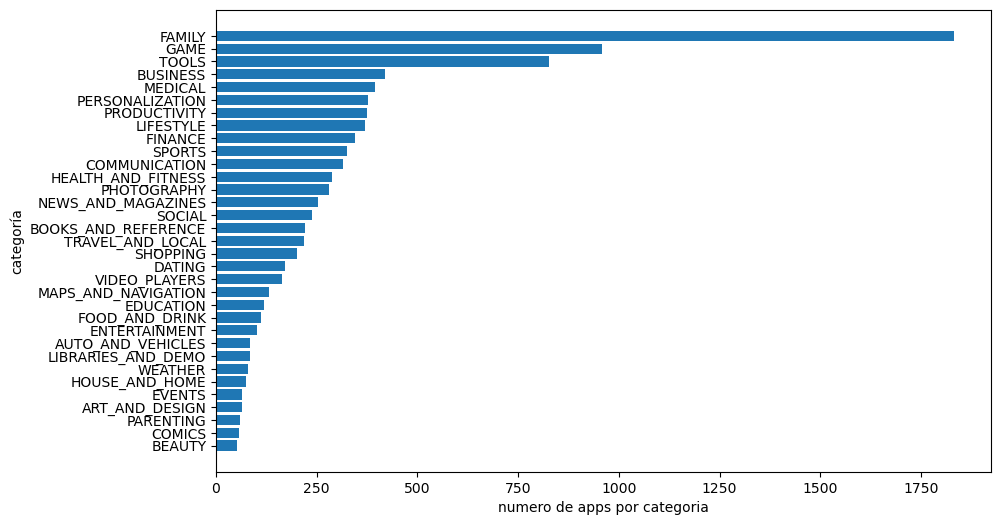

In [44]:
#Histograma de apps por categoría
import matplotlib.pyplot as plt
import numpy as np
plt.figure(figsize=(10, 6))
plt.barh(x_f,y_f,align="center")
plt.xlabel("numero de apps por categoria")
plt.ylabel("categoría")
plt.show()

In [46]:
#promedio calificación de las apps
avg_app_rating = apps["Rating"].mean()
print('Average app rating = ', avg_app_rating)


Average app rating =  4.173243045387994


In [48]:
#promedio de calificaciones de apps por categoria
avg_app_rating_category = apps.groupby("Category")["Rating"].mean().sort_values(ascending=True).reset_index(name='Rating')
avg_app_rating_category


,Category,Rating
0,DATING,3.970149
1,MAPS_AND_NAVIGATION,4.036441
2,TOOLS,4.039554
3,VIDEO_PLAYERS,4.044595
4,TRAVEL_AND_LOCAL,4.069519
5,LIFESTYLE,4.093355
6,BUSINESS,4.098479
7,FINANCE,4.115563
8,COMMUNICATION,4.121484
9,NEWS_AND_MAGAZINES,4.121569


In [50]:
#creación de arrays de categoría y de rating
x_r=avg_app_rating_category["Category"]
y_r=avg_app_rating_category["Rating"]

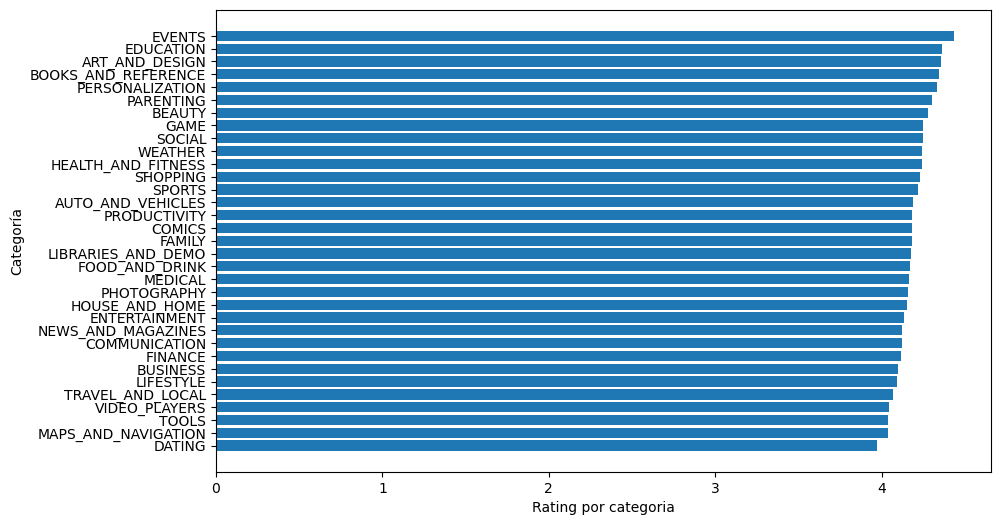

In [52]:
plt.figure(figsize=(10, 6))
plt.barh(x_r,y_r,align="center")
plt.xlabel("Rating por categoria")
plt.ylabel("Categoría")
plt.show()

In [54]:
import seaborn as sns


In [56]:
sns.set_style("darkgrid")


In [58]:
# Filtro de las filas donde los valores de 'Rating' y 'Size' no son nulos
apps_with_size_and_rating_present =apps.dropna(subset=['Rating', 'Size'])

In [60]:
# Filtro de las categorías con al menos 250 apps

large_categories = apps_with_size_and_rating_present.groupby("Category").filter(lambda x: len(x) >= 250)
large_categories

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
839,Citibanamex Movil,FINANCE,3.6,52306,42.0,5000000.0,Free,0.0,Everyone,Finance,"July 27, 2018",20.1.0,5.0 and up
841,KTB Netbank,FINANCE,3.8,42644,19.0,5000000.0,Free,0.0,Everyone,Finance,"June 28, 2018",8.18,4.2 and up
842,Mobile Bancomer,FINANCE,4.2,278082,70.0,10000000.0,Free,0.0,Everyone,Finance,"July 30, 2018",10.78,4.0.3 and up
843,Nedbank Money,FINANCE,4.2,6076,32.0,500000.0,Free,0.0,Everyone,Finance,"July 28, 2018",4.1.1-0-prod,4.2 and up
844,SCB EASY,FINANCE,4.2,112656,93.0,5000000.0,Free,0.0,Everyone,Finance,"July 19, 2018",3.9.0,4.1 and up
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9645,Fr Agnel Ambarnath,FAMILY,4.2,117,13.0,5000.0,Free,0.0,Everyone,Education,"June 13, 2018",2.0.20,4.0.3 and up
9652,FR Calculator,FAMILY,4.0,7,2.6,500.0,Free,0.0,Everyone,Education,"June 18, 2017",1.0.0,4.1 and up
9654,Sya9a Maroc - FR,FAMILY,4.5,38,53.0,5000.0,Free,0.0,Everyone,Education,"July 25, 2017",1.48,4.1 and up
9655,Fr. Mike Schmitz Audio Teachings,FAMILY,5.0,4,3.6,100.0,Free,0.0,Everyone,Education,"July 6, 2018",1,4.1 and up


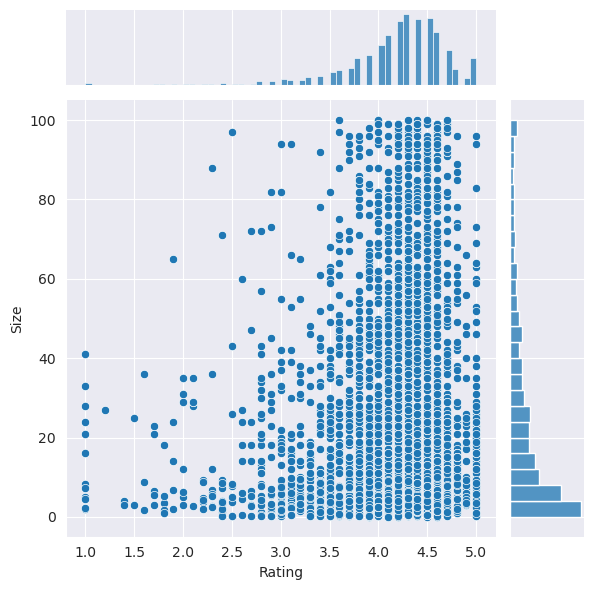

In [62]:
# Gráfica size vs. rating
plt1 = sns.jointplot(x = large_categories["Rating"], y = large_categories["Size"])
plt1.savefig('rating_size.png')

In [68]:
# Selección de las apps de paga 'Type' = 'Paid'
paid_apps = apps_with_size_and_rating_present[apps_with_size_and_rating_present["Type"]=="Paid"]
paid_apps


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
233,TurboScan: scan documents and receipts in PDF,BUSINESS,4.7,11442,6.8,100000.0,Paid,4.99,Everyone,Business,"March 25, 2018",1.5.2,4.0 and up
234,Tiny Scanner Pro: PDF Doc Scan,BUSINESS,4.8,10295,39.0,100000.0,Paid,4.99,Everyone,Business,"April 11, 2017",3.4.6,3.0 and up
407,Calculator,DATING,2.6,57,6.2,1000.0,Paid,6.99,Everyone,Dating,"October 25, 2017",1.1.6,4.0 and up
411,AMBW Dating App: Asian Men Black Women Interra...,DATING,3.5,2,17.0,100.0,Paid,7.99,Mature 17+,Dating,"January 21, 2017",1.0.1,4.0 and up
687,Sago Mini Hat Maker,EDUCATION,4.9,11,63.0,1000.0,Paid,3.99,Everyone,Education;Pretend Play,"July 24, 2017",1,4.0.3 and up
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9513,FO Bixby,PERSONALIZATION,5.0,5,0.9,100.0,Paid,0.99,Everyone,Personalization,"April 25, 2018",0.2,7.0 and up
9520,Mu.F.O.,GAME,5.0,2,16.0,1.0,Paid,0.99,Everyone,Arcade,"March 3, 2017",1,2.3 and up
9579,Fast Tract Diet,HEALTH_AND_FITNESS,4.4,35,2.4,1000.0,Paid,7.99,Everyone,Health & Fitness,"August 8, 2018",1.9.3,4.2 and up
9600,Trine 2: Complete Story,GAME,3.8,252,11.0,10000.0,Paid,16.99,Teen,Action,"February 27, 2015",2.22,5.0 and up


In [100]:
# Selección de las apps de paga 'Type' = 'Paid'
paid_apps = large_categories[large_categories["Type"]=="Paid"]
paid_apps


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
1488,The Game of Life,GAME,4.4,18621,63.0,100000.0,Paid,2.99,Everyone,Board,"July 4, 2018",2.1.2,4.4 and up
1489,Clue,GAME,4.6,19922,35.0,100000.0,Paid,1.99,Everyone 10+,Board,"July 30, 2018",2.2.5,5.0 and up
1490,The Room: Old Sins,GAME,4.9,21119,48.0,100000.0,Paid,4.99,Everyone,Puzzle,"April 18, 2018",1.0.1,4.4 and up
1491,The Escapists,GAME,4.4,7412,84.0,100000.0,Paid,4.99,Teen,Strategy,"April 26, 2018",1.1.0,2.3 and up
1492,Farming Simulator 18,GAME,4.5,18125,15.0,100000.0,Paid,4.99,Everyone,Simulation;Education,"July 9, 2018",Varies with device,4.4 and up
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9505,Fruit Ninja Classic,GAME,4.3,85468,36.0,1000000.0,Paid,0.99,Everyone,Arcade,"June 8, 2018",2.4.1.485300,4.0.3 and up
9513,FO Bixby,PERSONALIZATION,5.0,5,0.9,100.0,Paid,0.99,Everyone,Personalization,"April 25, 2018",0.2,7.0 and up
9520,Mu.F.O.,GAME,5.0,2,16.0,1.0,Paid,0.99,Everyone,Arcade,"March 3, 2017",1,2.3 and up
9600,Trine 2: Complete Story,GAME,3.8,252,11.0,10000.0,Paid,16.99,Teen,Action,"February 27, 2015",2.22,5.0 and up


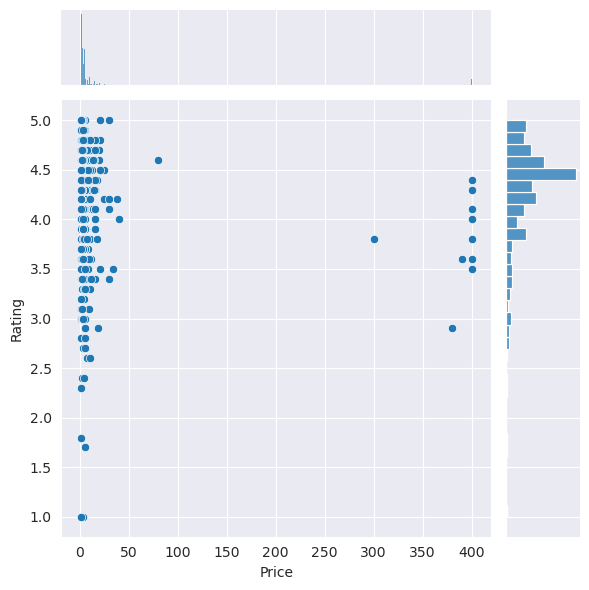

In [85]:
# Grafica price vs. rating de las aplicaciones de paga
plt2 = sns.jointplot(x = paid_apps["Price"], y = paid_apps["Rating"])
plt2.savefig('rating_price1.png')

plt.show()

,Category,App,Price
187,BUSINESS,Visual Voicemail by MetroPCS,0.0
188,BUSINESS,Indeed Job Search,0.0
189,BUSINESS,Uber Driver,0.0
190,BUSINESS,ADP Mobile Solutions,0.0
191,BUSINESS,Snag - Jobs Hiring Now,0.0
...,...,...,...
9653,BUSINESS,FR Forms,0.0
9654,FAMILY,Sya9a Maroc - FR,0.0
9655,FAMILY,Fr. Mike Schmitz Audio Teachings,0.0
9656,MEDICAL,Parkinson Exercices FR,0.0


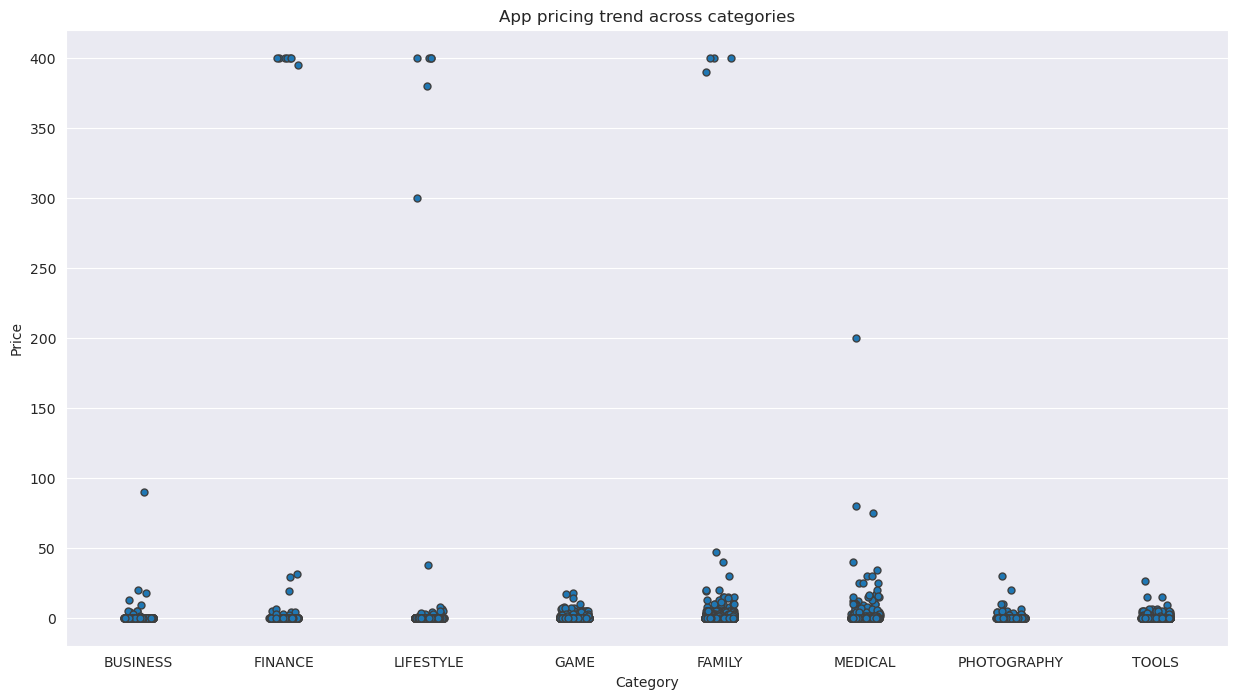

In [104]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots()
fig.set_size_inches(15, 8)

# Lista de categorías populares
popular_app_cats = apps[apps.Category.isin(['GAME', 'FAMILY', 'PHOTOGRAPHY',
                                            'MEDICAL', 'TOOLS', 'FINANCE',
                                            'LIFESTYLE','BUSINESS'])]

# Tendencia de precio graficando el Precio por Categoría
ax = sns.stripplot(x = popular_app_cats["Category"], y = popular_app_cats["Price"], jitter=True, linewidth=1)
ax.set_title('App pricing trend across categories')

# Selección de las apps con un precio mayor a 200
apps_above_200 = popular_app_cats.groupby("Price").filter(lambda x: len(x) > 200)

apps_above_200[['Category', 'App', 'Price']]

In [108]:
# Selección de las apps de paga 'Type' = 'Paid'
free_apps = apps_with_size_and_rating_present[apps_with_size_and_rating_present["Type"]=="Free"]
free_apps
# Selección de las apps de paga 'Type' = 'Paid'
paid_apps = apps_with_size_and_rating_present[apps_with_size_and_rating_present["Type"]=="Paid"]
paid_apps



,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
233,TurboScan: scan documents and receipts in PDF,BUSINESS,4.7,11442,6.8,100000.0,Paid,4.99,Everyone,Business,"March 25, 2018",1.5.2,4.0 and up
234,Tiny Scanner Pro: PDF Doc Scan,BUSINESS,4.8,10295,39.0,100000.0,Paid,4.99,Everyone,Business,"April 11, 2017",3.4.6,3.0 and up
407,Calculator,DATING,2.6,57,6.2,1000.0,Paid,6.99,Everyone,Dating,"October 25, 2017",1.1.6,4.0 and up
411,AMBW Dating App: Asian Men Black Women Interra...,DATING,3.5,2,17.0,100.0,Paid,7.99,Mature 17+,Dating,"January 21, 2017",1.0.1,4.0 and up
687,Sago Mini Hat Maker,EDUCATION,4.9,11,63.0,1000.0,Paid,3.99,Everyone,Education;Pretend Play,"July 24, 2017",1,4.0.3 and up
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9513,FO Bixby,PERSONALIZATION,5.0,5,0.9,100.0,Paid,0.99,Everyone,Personalization,"April 25, 2018",0.2,7.0 and up
9520,Mu.F.O.,GAME,5.0,2,16.0,1.0,Paid,0.99,Everyone,Arcade,"March 3, 2017",1,2.3 and up
9579,Fast Tract Diet,HEALTH_AND_FITNESS,4.4,35,2.4,1000.0,Paid,7.99,Everyone,Health & Fitness,"August 8, 2018",1.9.3,4.2 and up
9600,Trine 2: Complete Story,GAME,3.8,252,11.0,10000.0,Paid,16.99,Teen,Action,"February 27, 2015",2.22,5.0 and up


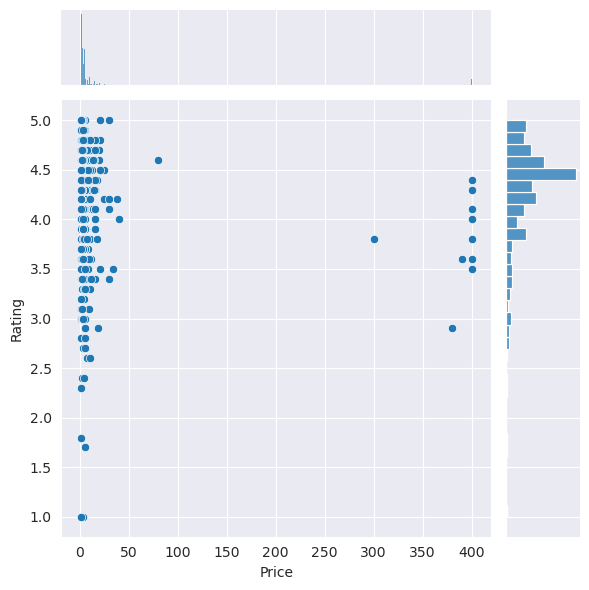

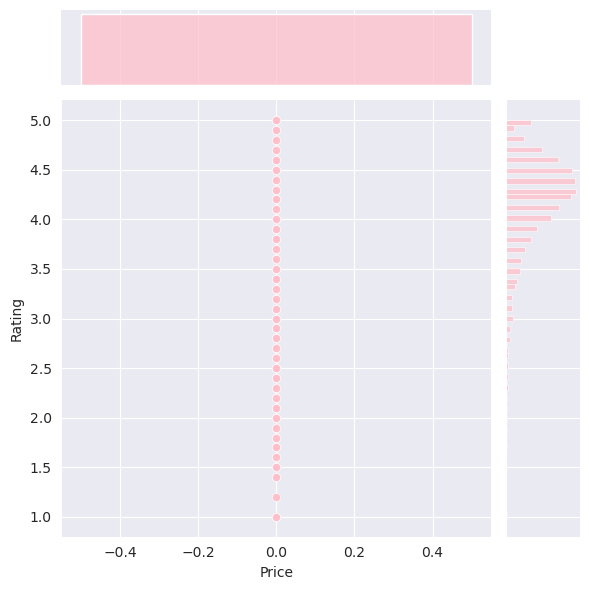

In [110]:
# Grafica price vs. rating de las aplicaciones de paga
plt2 = sns.jointplot(x = paid_apps["Price"], y = paid_apps["Rating"])
plt3 = sns.jointplot(x = free_apps["Price"], y = free_apps["Rating"], color="pink")
plt.show()

In [115]:
#selección de filas con tipo "Paid" y "Free"
app_paid_and_free= apps[apps.Type.isin(['Paid', 'Free'])]
app_paid_and_free.head()


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19.0,10000.0,Free,0.0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,500000.0,Free,0.0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7,5000000.0,Free,0.0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25.0,50000000.0,Free,0.0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8,100000.0,Free,0.0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [118]:
#calificación promedio por categoría
avg_app_rating_category = apps.groupby("Category")["Rating"].mean().sort_values(ascending=True).reset_index(name='Rating')
avg_app_rating_category

,Category,Rating
0,DATING,3.970149
1,MAPS_AND_NAVIGATION,4.036441
2,TOOLS,4.039554
3,VIDEO_PLAYERS,4.044595
4,TRAVEL_AND_LOCAL,4.069519
5,LIFESTYLE,4.093355
6,BUSINESS,4.098479
7,FINANCE,4.115563
8,COMMUNICATION,4.121484
9,NEWS_AND_MAGAZINES,4.121569


In [120]:
#reviews promedio por tipo de precio
avg_app_rating_category = app_paid_and_free.groupby("Type")["Reviews"].mean().sort_values(ascending=True).reset_index(name='Reviews')
avg_app_rating_category


,Type,Reviews
0,Paid,8724.887566
1,Free,234243.688532


In [122]:
#tamaño promedio por tipo de precio
avg_app_rating_category = app_paid_and_free.groupby("Type")["Size"].mean().sort_values(ascending=True).reset_index(name='Size')
avg_app_rating_category

,Type,Size
0,Paid,19.012993
1,Free,20.517555


In [99]:
#lectura de los datos de sentimientos
reviews_df=pd.read_csv('user_reviews.csv')
reviews_df.head()

,App,Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,NaN,NaN,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000


In [101]:
# Unión los dos DataFrames (join)
merged_df = pd.merge(apps,reviews_df, on='App', how='inner')
merged_df

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,500000.0,Free,0.0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,A kid's excessive ads. The types ads allowed a...,Negative,-0.250,1.000000
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,500000.0,Free,0.0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,It bad >:(,Negative,-0.725,0.833333
2,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,500000.0,Free,0.0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,like,Neutral,0.000,0.000000
3,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,500000.0,Free,0.0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,NaN,NaN,NaN,NaN
4,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,500000.0,Free,0.0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,I love colors inspyering,Positive,0.500,0.600000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61551,A+ Gallery - Photos & Videos,PHOTOGRAPHY,4.5,223941,NaN,10000000.0,Free,0.0,Everyone,Photography,"August 6, 2018",Varies with device,Varies with device,NaN,NaN,NaN,NaN
61552,A+ Gallery - Photos & Videos,PHOTOGRAPHY,4.5,223941,NaN,10000000.0,Free,0.0,Everyone,Photography,"August 6, 2018",Varies with device,Varies with device,NaN,NaN,NaN,NaN
61553,A+ Gallery - Photos & Videos,PHOTOGRAPHY,4.5,223941,NaN,10000000.0,Free,0.0,Everyone,Photography,"August 6, 2018",Varies with device,Varies with device,Too much ads,Positive,0.200,0.200000
61554,A+ Gallery - Photos & Videos,PHOTOGRAPHY,4.5,223941,NaN,10000000.0,Free,0.0,Everyone,Photography,"August 6, 2018",Varies with device,Varies with device,Just allow time ...,Neutral,0.000,0.000000


In [103]:
# Eliminación de los valores nulos (NA) de las columnas Sentiment y Review
merged_df = merged_df.dropna(subset = ['Sentiment', 'Review'])
merged_df


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,500000.0,Free,0.0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,A kid's excessive ads. The types ads allowed a...,Negative,-0.250000,1.000000
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,500000.0,Free,0.0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,It bad >:(,Negative,-0.725000,0.833333
2,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,500000.0,Free,0.0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,like,Neutral,0.000000,0.000000
4,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,500000.0,Free,0.0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,I love colors inspyering,Positive,0.500000,0.600000
5,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,500000.0,Free,0.0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,I hate,Negative,-0.800000,0.900000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61540,A+ Gallery - Photos & Videos,PHOTOGRAPHY,4.5,223941,NaN,10000000.0,Free,0.0,Everyone,Photography,"August 6, 2018",Varies with device,Varies with device,Overall great app. Best gallery seen far,Positive,0.475000,0.512500
61546,A+ Gallery - Photos & Videos,PHOTOGRAPHY,4.5,223941,NaN,10000000.0,Free,0.0,Everyone,Photography,"August 6, 2018",Varies with device,Varies with device,"Recommended, 100% love it, keep good work dev ...",Positive,0.566667,0.733333
61553,A+ Gallery - Photos & Videos,PHOTOGRAPHY,4.5,223941,NaN,10000000.0,Free,0.0,Everyone,Photography,"August 6, 2018",Varies with device,Varies with device,Too much ads,Positive,0.200000,0.200000
61554,A+ Gallery - Photos & Videos,PHOTOGRAPHY,4.5,223941,NaN,10000000.0,Free,0.0,Everyone,Photography,"August 6, 2018",Varies with device,Varies with device,Just allow time ...,Neutral,0.000000,0.000000


In [117]:
#selección de filas con tipo "Free" y "Paid" 
app_paid_and_free= merged_df[merged_df.Type.isin(['Paid', 'Free'])]
app_paid_and_free.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,500000.0,Free,0.0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,A kid's excessive ads. The types ads allowed a...,Negative,-0.250,1.000000
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,500000.0,Free,0.0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,It bad >:(,Negative,-0.725,0.833333
2,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,500000.0,Free,0.0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,like,Neutral,0.000,0.000000
4,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,500000.0,Free,0.0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,I love colors inspyering,Positive,0.500,0.600000
5,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,500000.0,Free,0.0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,I hate,Negative,-0.800,0.900000


In [107]:
#revisar si hay caracteres raros en los nombres de las columnas
print(merged_df.columns)
merged_df.columns = merged_df.columns.str.strip()

Index(['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type',
       'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver',
       'Android Ver', 'Review', 'Sentiment', 'Sentiment_Polarity',
       'Sentiment_Subjectivity'],
      dtype='object')


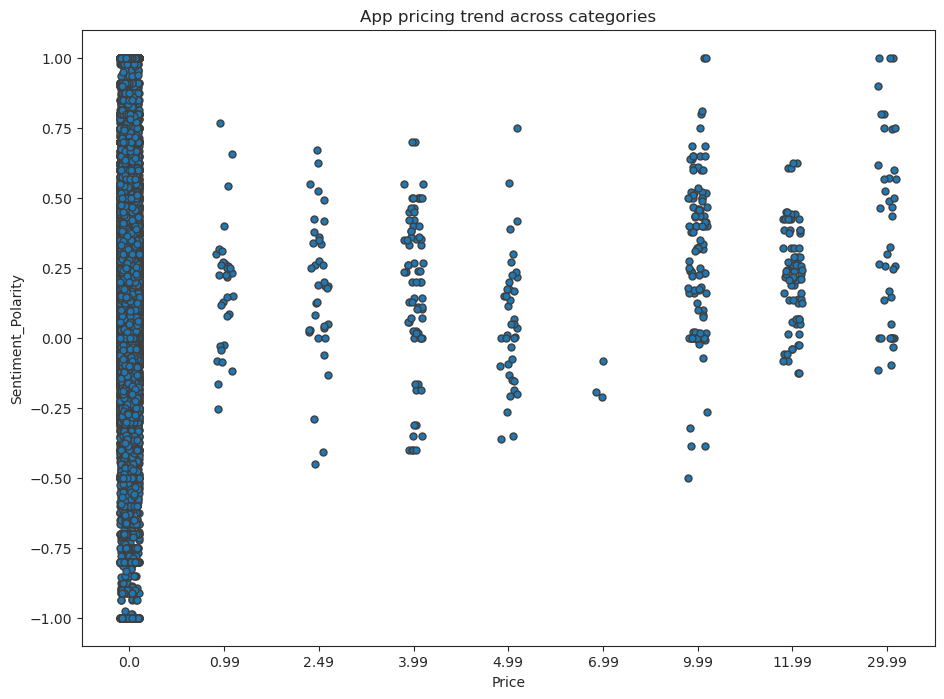

In [109]:
# Grafica la polaridad de sentimientos para apps gratuitas y de paga
sns.set_style('ticks')
fig, ax = plt.subplots()
fig.set_size_inches(11, 8)



# Aislamiento de los precios de paga y gratis
app_free_and_paid = merged_df[merged_df.Type.isin(['Free', 'Paid'])]

# Examina la polaridad de sentimientos graficando la polaridad por precio 
ax = sns.stripplot(x = app_free_and_paid["Price"], y = app_free_and_paid["Sentiment_Polarity"], jitter=True, linewidth=1)
ax.set_title('App pricing trend across categories')
plt.savefig('polarizacion_sentimientos.png')




